# Week 2 — Deep Learning Mathematics: Self-Attention

This notebook demonstrates the Transformer self-attention mechanism on an mRNA nucleotide sequence. The implementation is kept in `src/attention.py`; this notebook uses those functions rather than duplicating the implementation.

Self-attention derives three matrices from the same input embeddings:
- **Q (Query):** what each sequence position is looking for.
- **K (Key):** what each position offers for matching.
- **V (Value):** the content contributed after the attention weights are calculated.

The scaled dot-product formula is:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from attention import encode_sequence, self_attention, plot_attention, EMBED_DIM

## 1. Encode the sample mRNA sequence

The PRD uses the 15-base sequence `ACGUACGUACGGCUA`. Each nucleotide is represented by an 8-dimensional embedding vector.

In [4]:
sequence = "ACGUACGUACGGCUA"
X = encode_sequence(sequence)

print("Sequence:", sequence)
print("Sequence length:", len(sequence))
print("Embedding dimension:", EMBED_DIM)
print("Encoded matrix shape:", X.shape)

Sequence: ACGUACGUACGGCUA
Sequence length: 15
Embedding dimension: 8
Encoded matrix shape: (15, 8)


## 2. Compute Q, K, V and attention

The attention implementation creates randomly initialized linear projection matrices for Q, K and V. The scaled dot products are converted into row-wise probabilities using softmax.

In [5]:
attention_weights, attention_output = self_attention(X)

print("Attention weights shape:", attention_weights.shape)
print("Attention output shape:", attention_output.shape)
print("Expected attention shape:", (len(sequence), len(sequence)))

Attention weights shape: (15, 15)
Attention output shape: (15, 8)
Expected attention shape: (15, 15)


## 3. Softmax sanity check

Every row of the attention matrix represents a probability distribution over the sequence positions, so each row must sum to 1.

In [6]:
row_sums = attention_weights.sum(axis=1)

print("Row sums:")
print(row_sums)
print("All rows sum to 1:", np.allclose(row_sums, 1.0))

assert attention_weights.shape == (len(sequence), len(sequence))
assert np.allclose(row_sums, 1.0)


Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
All rows sum to 1: True


## 4. Attention heatmap

The heatmap shows how strongly each sequence position attends to every other position. The horizontal axis is the position being attended **to**, while the vertical axis is the position attending **from**.

Heatmap saved to: c:\Users\ADMIN\OneDrive\Documents\GitHub\mRNA-VIP-Clinical-Safety-Intelligence\outputs\figures\attention_heatmap.png


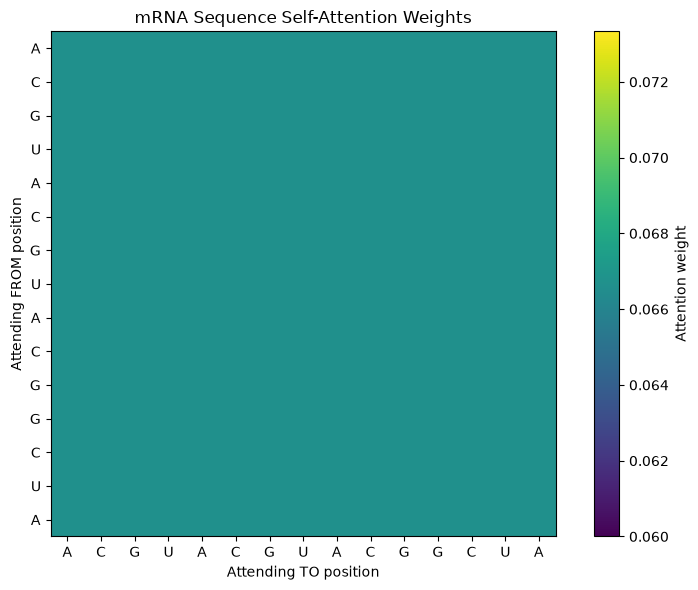

In [7]:
heatmap_path = PROJECT_ROOT / "outputs" / "figures" / "attention_heatmap.png"
heatmap_path.parent.mkdir(parents=True, exist_ok=True)
plot_attention(attention_weights, sequence, str(heatmap_path))

print("Heatmap saved to:", heatmap_path)

plt.figure(figsize=(8, 6))
plt.imshow(attention_weights)
plt.xticks(range(len(sequence)), list(sequence))
plt.yticks(range(len(sequence)), list(sequence))
plt.xlabel("Attending TO position")
plt.ylabel("Attending FROM position")
plt.title("mRNA Sequence Self-Attention Weights")
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()

## 5. Interpretation

In this implementation, the mRNA sequence is first converted into an embedding matrix, where each nucleotide is represented by an 8-dimensional vector. The same input embeddings are then projected into three spaces to form the Query (Q), Key (K), and Value (V) matrices. Q and K are compared through a dot product to produce a score for every pair of sequence positions. Dividing these scores by the square root of the key dimension stabilizes the values before softmax converts each row into attention probabilities. Finally, the probabilities weight the V vectors to produce the attention output.

The heatmap shows how much each position attends to every other position. In this example, the weights are fairly similar across the matrix rather than forming a few very strong hotspots. That is reasonable because the Q, K, and V projection matrices are randomly initialized and the attention mechanism has not been trained on biological sequence data. The repeated nucleotide bases can also share the same embedding because the vocabulary contains one vector for each of A, C, G, and U. Therefore, the heatmap should be interpreted as a demonstration of the attention calculation rather than as a learned biological relationship. The important result is that the mechanism produces a valid sequence-by-sequence attention matrix whose rows form probability distributions.